# L6 · Xavier vs He initialization through a deep ReLU network

**One idea:** ReLU zeroes about half its inputs, halving signal energy per layer.
**He** ($\operatorname{Var}(w)=2/n$) compensates and keeps activation scale stable
across depth; Xavier ($1/n$) slowly vanishes, and mis-scaled inits vanish/explode
**exponentially** in depth.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

n, depth = 256, 50                       # width, number of layers

def propagate(var_w):
    h = np.random.normal(0, 1, size=n)   # input activations, Var=1
    stds = []
    for _ in range(depth):
        W = np.random.normal(0, np.sqrt(var_w), size=(n, n))
        z = W @ h
        h = np.maximum(0, z)             # ReLU
        stds.append(h.std())
    return np.array(stds)

inits = {
    "tiny  (0.5/n)": 0.5/n,
    "Xavier (1/n)":  1.0/n,
    "He     (2/n)":  2.0/n,
    "large  (4/n)":  4.0/n,
}

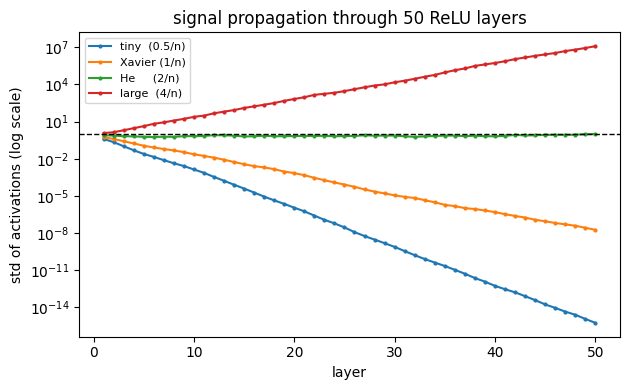

In [2]:
plt.figure(figsize=(6.4, 4))
for name, var_w in inits.items():
    stds = propagate(var_w)
    plt.semilogy(range(1, depth+1), stds, marker=".", ms=4, label=name)
plt.axhline(1.0, color="k", ls="--", lw=1)
plt.xlabel("layer"); plt.ylabel("std of activations (log scale)")
plt.title("signal propagation through 50 ReLU layers")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

In [3]:
print(f"{'init':16s} {'std @ layer 50':>16s}")
for name, var_w in inits.items():
    s = propagate(var_w)[-1]
    print(f"{name:16s} {s:16.3e}")

init               std @ layer 50


tiny  (0.5/n)           9.296e-16


Xavier (1/n)            1.941e-08


He     (2/n)            4.541e-01


large  (4/n)            1.313e+07


## Takeaway
- **He ($2/n$) keeps activation std near 1** through 50 ReLU layers.
- **Xavier ($1/n$)** loses ~half the energy per ReLU layer, so signal decays.
- Too-small inits vanish and too-large inits explode — both **exponentially** in
  depth. Matching the init to the activation is what makes deep nets trainable.